<img src='https://www.tomic.com/wp-content/uploads/2019/04/get-rid-of-chest-fat.jpg'>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
df.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


**Plot The Data**

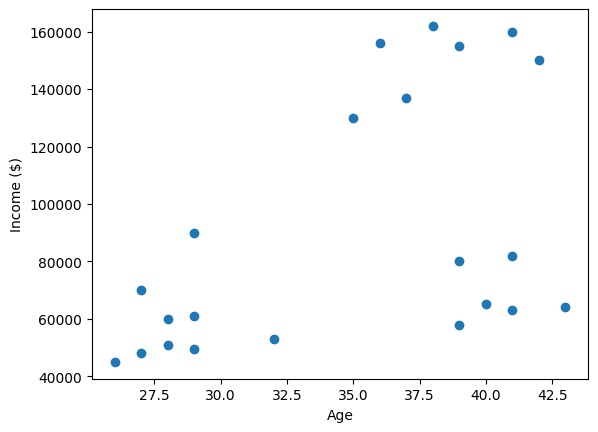

In [4]:
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.show()

K-Means Clustering

In [5]:
model = KMeans(n_clusters = 3, n_init = 10)

In [6]:
model.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

**We fit the model without scaling**


In [7]:
model = model.fit(df[['Age', 'Income($)']])

In [8]:
y_pred = model.predict(df[['Age', 'Income($)']])
df['Cluster'] = y_pred
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


In [9]:
model.cluster_centers_

array([[3.40000000e+01, 8.05000000e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.29090909e+01, 5.61363636e+04]])

**Plot the Clusters**

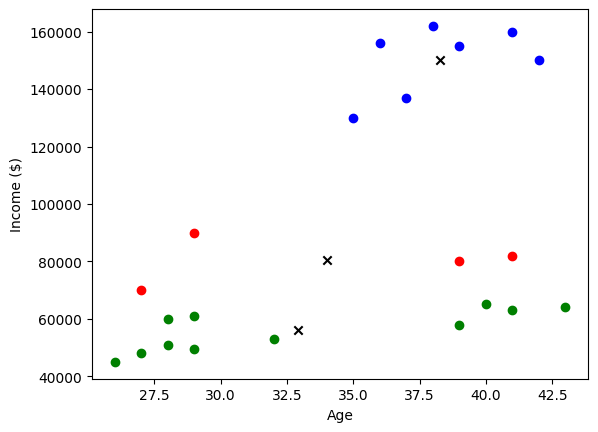

In [10]:
df0 = df[df['Cluster'] == 0]
df1 = df[df['Cluster'] == 1]
df2 = df[df['Cluster'] == 2]

plt.scatter(df0['Age'], df0['Income($)'], color = 'red')
plt.scatter(df1['Age'], df1['Income($)'], color = 'blue')
plt.scatter(df2['Age'], df2['Income($)'], color = 'green')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], color = 'black', marker = 'x')

plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.show()

**Fit and predict with scaled data**

In [11]:
# Creating a scaler 
scaler = MinMaxScaler()

# Fit and apply the scaler
df['Scaled Age'] = scaler.fit_transform(df[['Age']])
df['Scaled Income'] = scaler.fit_transform(df[['Income($)']])

In [60]:
df.head()

,Name,Age,Income($),Cluster,Scaled Age,Scaled Income
0,Rob,27,70000,0,0.058824,0.213675
1,Michael,29,90000,0,0.176471,0.384615
2,Mohan,29,61000,2,0.176471,0.136752
3,Ismail,28,60000,2,0.117647,0.128205
4,Kory,42,150000,1,0.941176,0.897436


**Plot the Data**

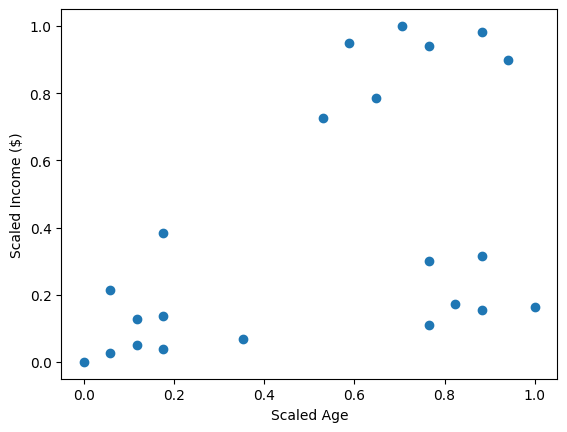

In [13]:
plt.scatter(df['Scaled Age'], df['Scaled Income'])
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income ($)')
plt.show()

In [14]:
model = KMeans(n_clusters = 3, n_init = 10)

In [15]:
model.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

**We fit the model with scaling**

In [16]:
model = model.fit(df[['Scaled Age', 'Scaled Income']])

In [17]:
y_pred = model.predict(df[['Scaled Age', 'Scaled Income']])
df['Cluster'] = y_pred
df.head()

,Name,Age,Income($),Cluster,Scaled Age,Scaled Income
0,Rob,27,70000,0,0.058824,0.213675
1,Michael,29,90000,0,0.176471,0.384615
2,Mohan,29,61000,0,0.176471,0.136752
3,Ismail,28,60000,0,0.117647,0.128205
4,Kory,42,150000,2,0.941176,0.897436


In [18]:
model.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ],
       [0.72268908, 0.8974359 ]])

**Plot the Clusters**


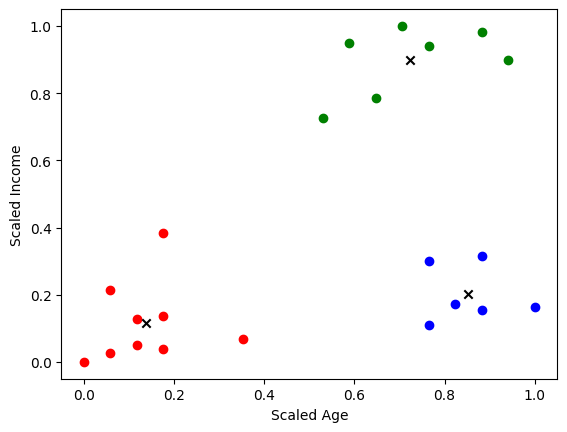

In [19]:
df0 = df[df['Cluster'] == 0]
df1 = df[df['Cluster'] == 1]
df2 = df[df['Cluster'] == 2]

plt.scatter(df0['Scaled Age'], df0['Scaled Income'], color = 'red')
plt.scatter(df1['Scaled Age'], df1['Scaled Income'], color = 'blue')
plt.scatter(df2['Scaled Age'], df2['Scaled Income'], color = 'green')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], color = 'black', marker = 'x')

plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.show()

**Elbow Plot for finding optimal number of clusters**

In [20]:
# Create a list for sorting the models scores
scoreList = []
kRange = range(1, 10)
for k in kRange:
    model = KMeans(n_clusters = k, n_init = 10)
    model.fit(df[['Scaled Age', 'Scaled Income']])
    scoreList.append(model.inertia_)

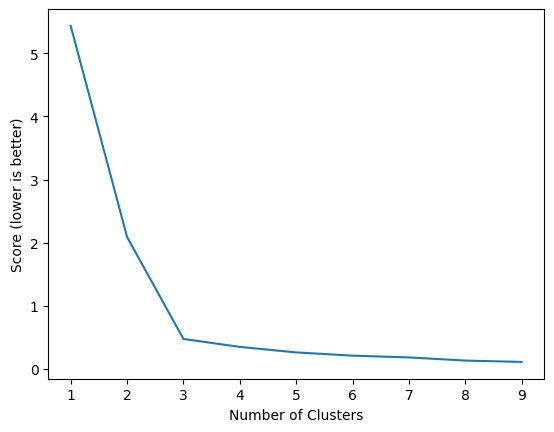

In [21]:
plt.plot(kRange, scoreList)

plt.xlabel('Number of Clusters')
plt.ylabel('Score (lower is better)')
plt.show()

At the point where the curve flattens, we see the optimal number of clusters.

**The End**